# UHC 청구서 관련 내용 전처리

In [2]:
#!pip install langchain-community

In [3]:
#!pip install pymupdf

In [4]:
#데이터 로드
from pathlib import Path

BASE_DIR = Path.cwd().parent  
CLAIM_DIR = BASE_DIR / "data" / "claim"
OUTPUT_DIR = BASE_DIR / "outputs" / "claim"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

claim_files = list(CLAIM_DIR.glob("*.pdf"))
claim_files

[WindowsPath('c:/SKN_24/4차 프로젝트 개인/전처리/UHC/data/claim/MBR-C-26437_UHCG_Expatriate_Insurance_Claim_Form_200914_Editable.pdf'),
 WindowsPath('c:/SKN_24/4차 프로젝트 개인/전처리/UHC/data/claim/MBR-EXP-1694500-CF Dental Only Member Claim Form_230201_HRPrint.pdf')]

In [5]:
DOCUMENT_TYPE = "claim_form"
INSURER = "UnitedHealthcare Global"

In [6]:
#메타데이터도 고정
def build_claim_metadata(file_path, page_num):
    return {
        "insurer": "UnitedHealthcare Global",
        "document_type": "claim_form",
        "source_file": file_path.name,
        "page": page_num,
        "region_scope": "global",
        "korea_applicability": "conditional",
        "language": "en"
    }

---

In [7]:
#from langchain_community.document_loaders import PyMuPDFLoader
#
#def load_pdf_pages(file_path):
#    loader = PyMuPDFLoader(str(file_path))
#    docs = loader.load()
#
#    pages = []
#    for doc in docs:
#        pages.append({
#            "page": doc.metadata.get("page", 0) + 1,
#            "text": doc.page_content
#        })
#    return pages

In [ ]:
#pip install pymupdf

In [ ]:
import fitz 

def load_pdf_pages_ordered(file_path):
    doc = fitz.open(str(file_path))
    pages = []

    for page_idx, page in enumerate(doc):
        blocks = page.get_text("blocks")

        text_blocks = []
        for block in blocks:
            x0, y0, x1, y1, text, *_ = block

            if text.strip():
                text_blocks.append({
                    "x0": x0,
                    "y0": y0,
                    "text": text.strip()
                })

        # 위->아래
        # 같은 높이면 왼쪽 -> 오른쪽
        text_blocks = sorted(
            text_blocks,
            key=lambda b: (round(b["y0"], 1), round(b["x0"], 1))
        )

        page_text = "\n".join(block["text"] for block in text_blocks)

        pages.append({
            "page": page_idx + 1,
            "text": page_text
        })

    return pages

In [9]:
#papages = load_pdf_pages_ordered(claim_files[0])
#
#print(len(pages))
#print(pages[0]["text"][:2000])

In [10]:
#text = pages[0]["text"]
#
#print("Section 1 위치:", text.lower().find("section 1"))
#print("Patient 위치:", text.lower().find("patient"))
#print("Section 2 위치:", text.lower().find("section 2"))
#print("Reimbursement 위치:", text.lower().find("reimbursement"))

In [11]:
#for keyword in ["Section 1", "Patient Information", "Member ID", "Date of Birth"]:
#    print(keyword, keyword.lower() in pages[0]["text"].lower())

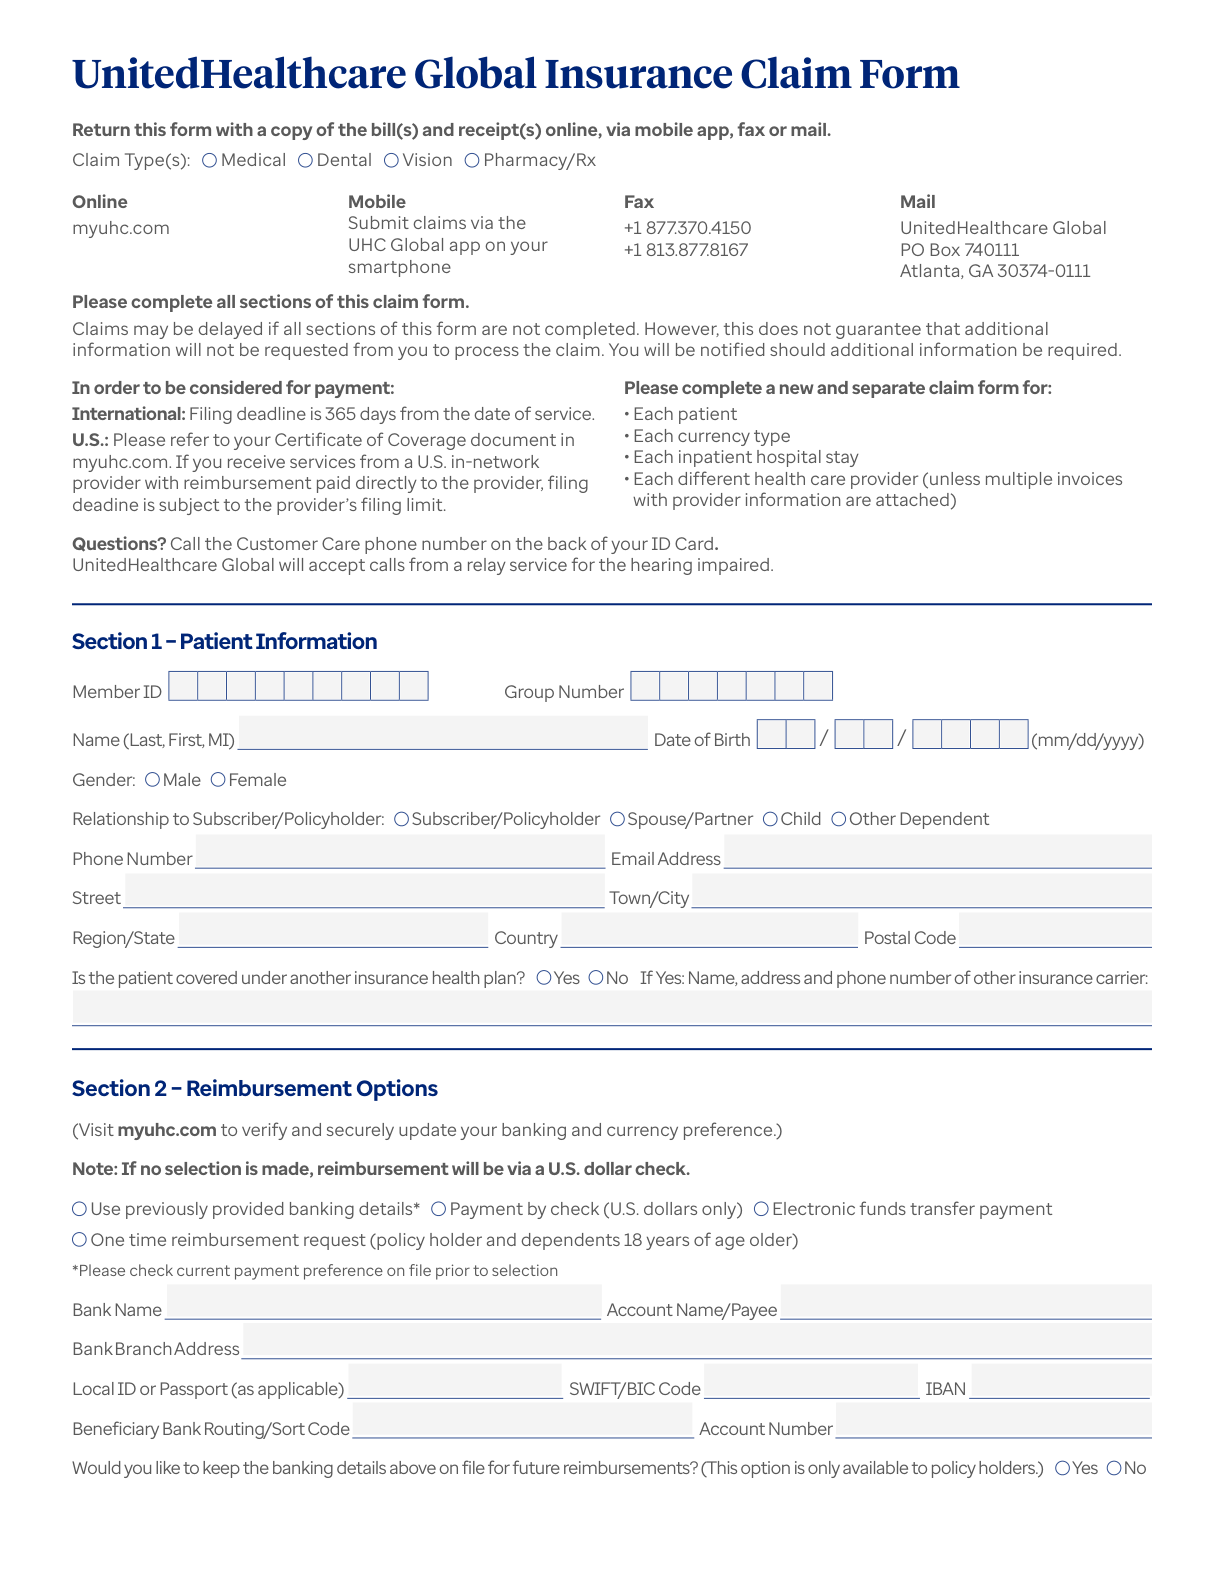

In [ ]:
#확인용
import fitz
from PIL import Image
import io

def show_pdf_page(file_path, page_num=0):
    doc = fitz.open(str(file_path))
    page = doc[page_num]

    pix = page.get_pixmap(matrix=fitz.Matrix(2, 2))
    img = Image.open(io.BytesIO(pix.tobytes("png")))

    display(img)
show_pdf_page(claim_files[0], 0)

In [16]:
def load_full_text(file_path):
    pages = load_pdf_pages_ordered(file_path)
    return "\n".join([p["text"] for p in pages])

In [17]:
import re

def split_claim_sections(text):
    pattern = r"(section\s*1.*?|section\s*2.*?|section\s*3.*?)"
    
    matches = re.split(r"(section\s*[123].*?)", text, flags=re.IGNORECASE)

    sections = []
    
    for i in range(1, len(matches), 2):
        title = matches[i]
        content = matches[i+1] if i+1 < len(matches) else ""
        
        sections.append({
            "title": title.strip(),
            "content": content.strip()
        })
    
    return sections

In [18]:
full_text = load_full_text(claim_files[0])

sections = split_claim_sections(full_text)

for s in sections:
    print("===")
    print(s["title"][:50])
    print(s["content"][:200])

===
Section 1
– Patient Information
Member ID  
		
Group Number
Name (Last, First, MI) 
  Date of Birth  
  /  
  /  
﻿
﻿
 (mm/dd/yyyy)
Gender:    Male    Female
Relationship to Subscriber/Policyholder:    Subscrib
===
Section 2
– Reimbursement Options
(Visit myuhc.com to verify and securely update your banking and currency preference.)
Note: If no selection is made, reimbursement will be via a U.S. dollar check.
Use previous
===
Section 3
– Claim Information
Provider/Facility Name
Provider/Facility Full Address
Provider Phone Number 
  Email Address
Where did the treatment take place?  City 
  Country
Type of Treatment
Diagnosis/Descri


In [ ]:
#섹션 번호 기준 정렬
def get_section_number(title):
    match = re.search(r"section\s*([123])", title, flags=re.IGNORECASE)
    if match:
        return int(match.group(1))
    return 99


sections = sorted(sections, key=lambda x: get_section_number(x["title"]))

for s in sections:
    print("===")
    print(s["title"][:80])
    print(s["content"][:200])

===
Section 1
– Patient Information
Member ID  
		
Group Number
Name (Last, First, MI) 
  Date of Birth  
  /  
  /  
﻿
﻿
 (mm/dd/yyyy)
Gender:    Male    Female
Relationship to Subscriber/Policyholder:    Subscrib
===
Section 2
– Reimbursement Options
(Visit myuhc.com to verify and securely update your banking and currency preference.)
Note: If no selection is made, reimbursement will be via a U.S. dollar check.
Use previous
===
Section 3
– Claim Information
Provider/Facility Name
Provider/Facility Full Address
Provider Phone Number 
  Email Address
Where did the treatment take place?  City 
  Country
Type of Treatment
Diagnosis/Descri


In [23]:
def make_claim_section_chunks(file_path):
    full_text = load_full_text(file_path)
    sections = split_claim_sections(full_text)
    sections = sorted(sections, key=lambda x: get_section_number(x["title"]))

    chunks = []

    for section in sections:
        title = section["title"].strip()
        content = section["content"].strip()

        if len(content) < 20:
            continue

        section_num = get_section_number(title)

        metadata = {
            "insurer": INSURER,
            "document_type": DOCUMENT_TYPE,
            "source_file": file_path.name,
            "source_category": "claim",
            "section_number": section_num,
            "section_title": title,
            "chunk_type": "claim_form_section",
            "region_scope": "global",
            "korea_applicability": "conditional",
            "language": "en",
            "claim_deadline_days": 365,
            "requires_invoice_or_receipt": True
        }

        chunks.append({
            "chunk_id": f"{file_path.stem}_section_{section_num}",
            "content": f"{title}\n{content}",
            "metadata": metadata
        })

    return chunks

In [24]:
test_chunks = make_claim_section_chunks(claim_files[0])

print(len(test_chunks))
for c in test_chunks:
    print(c["chunk_id"], c["metadata"]["section_number"], c["metadata"]["section_title"][:50])

3
MBR-C-26437_UHCG_Expatriate_Insurance_Claim_Form_200914_Editable_section_1 1 Section 1
MBR-C-26437_UHCG_Expatriate_Insurance_Claim_Form_200914_Editable_section_2 2 Section 2
MBR-C-26437_UHCG_Expatriate_Insurance_Claim_Form_200914_Editable_section_3 3 Section 3


In [25]:
test_chunks = make_claim_section_chunks(claim_files[1])

print(len(test_chunks))
for c in test_chunks:
    print(c["chunk_id"], c["metadata"]["section_number"], c["metadata"]["section_title"][:50])

3
MBR-EXP-1694500-CF Dental Only Member Claim Form_230201_HRPrint_section_1 1 Section 1
MBR-EXP-1694500-CF Dental Only Member Claim Form_230201_HRPrint_section_2 2 Section 2
MBR-EXP-1694500-CF Dental Only Member Claim Form_230201_HRPrint_section_3 3 Section 3


In [29]:
all_claim_chunks = []

for file_path in claim_files:
    all_claim_chunks.extend(make_claim_section_chunks(file_path))

print("전체 chunk 개수:", len(all_claim_chunks))

for c in all_claim_chunks:
    print(c["metadata"]["source_file"], c["metadata"]["section_number"], c["metadata"]["section_title"])

전체 chunk 개수: 6
MBR-C-26437_UHCG_Expatriate_Insurance_Claim_Form_200914_Editable.pdf 1 Section 1
MBR-C-26437_UHCG_Expatriate_Insurance_Claim_Form_200914_Editable.pdf 2 Section 2
MBR-C-26437_UHCG_Expatriate_Insurance_Claim_Form_200914_Editable.pdf 3 Section 3
MBR-EXP-1694500-CF Dental Only Member Claim Form_230201_HRPrint.pdf 1 Section 1
MBR-EXP-1694500-CF Dental Only Member Claim Form_230201_HRPrint.pdf 2 Section 2
MBR-EXP-1694500-CF Dental Only Member Claim Form_230201_HRPrint.pdf 3 Section 3


In [30]:
import json

output_path = OUTPUT_DIR / "uhc_claim_section_chunks.json"

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(all_claim_chunks, f, ensure_ascii=False, indent=2)

print(output_path)
print(output_path.exists())

c:\SKN_24\4차 프로젝트 개인\전처리\UHC\outputs\claim\uhc_claim_section_chunks.json
True
